<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>


# **🌳 Árboles de Decisión para Auditores Bancarios**
## Modelos Interpretables para Riesgo de Crédito y Fraude


## 1. FUNDAMENTOS TEÓRICOS

### 1.1 ¿Qué es un Árbol de Decisión?

Un **árbol de decisión** es un modelo de aprendizaje supervisado que divide el espacio de características de forma recursiva mediante reglas de decisión simples (if-then). Es especialmente valioso en banca por su **interpretabilidad**: permite explicar exactamente POR QUÉ se tomó una decisión crediticia.

```
Ejemplo de árbol para default crediticio:

                    ¿Score < 600?
                   /              \
                 SÍ               NO
                /                   \
        ¿Mora > 30 días?         ¿DTI > 0.40?
         /          \             /          \
       SÍ            NO         SÍ            NO
    RIESGO AUDITORÍA     REVISAR    REVISAR      APROBADO
    (85%)        (35%)      (22%)        (5%)
```

### 1.2 Criterios de División

#### Índice Gini (para clasificación)
$$Gini(t) = 1 - \sum_{k=1}^{K} p_k^2$$
donde $p_k$ es la proporción de clase $k$ en el nodo $t$.

**Gini = 0:** Nodo puro (todos de la misma clase)  
**Gini = 0.5:** Máxima impureza (50%-50%)

#### Entropía (Information Gain)
$$H(t) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

$$\text{Ganancia de Información} = H(\text{padre}) - \sum_{j} \frac{N_j}{N} H(\text{hijo}_j)$$

### 1.3 Parámetros Críticos de Control

| Parámetro | Efecto | Valor típico bancario |
|-----------|--------|----------------------|
| `max_depth` | Controla profundidad máxima | 3-7 |
| `min_samples_split` | Mínimo de muestras para dividir | 50-200 |
| `min_samples_leaf` | Mínimo de muestras en hoja | 20-100 |
| `max_features` | Variables consideradas en cada split | sqrt, log2 |
| `criterion` | Función de impureza | gini, entropy |

### 1.4 Ventajas Específicas para Auditoría Bancaria

✅ **Totalmente interpretable:** El árbol es una serie de reglas legibles  
✅ **No requiere escalado:** Variables en su escala original  
✅ **Capta no linealidades:** Sin necesidad de transformaciones  
✅ **Generación automática de reglas:** Para políticas de crédito  
✅ **Importancia de variables:** Identificación objetiva de drivers de riesgo  
✅ **Auditable por reguladores:** El árbol puede presentarse como política documentada  

### 1.5 Riesgos y Limitaciones

⚠️ **Overfitting:** Los árboles profundos memorizan el training  
⚠️ **Inestabilidad:** Pequeños cambios en datos → árboles muy diferentes  
⚠️ **Sesgo de variables:** Favorece variables con más valores únicos  
⚠️ **Fronteras de decisión rectangulares:** No captura diagonales  
⚠️ **Rendimiento inferior:** Suele perder frente a Random Forest o Boosting


## 2. CONFIGURACIÓN


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from scipy import stats

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Librerías cargadas")


✅ Librerías cargadas


## 3. CARGA DE DATOS DE AUDITORÍA BANCARIA


In [3]:
# === Carga del dataset común de auditoría bancaria ===
# Este CSV es el generado en el script introductorio de datos y desbalanceo.
# Debe estar en la misma carpeta que este notebook.

from pathlib import Path

CSV_PATH = Path("../../data/auditoria_bancaria_desbalanceada.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("/mnt/data/auditoria_bancaria_desbalanceada.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(
        "No se encuentra 'auditoria_bancaria_desbalanceada.csv'. "
        "Coloca el CSV en la misma carpeta que este notebook."
    )

df = pd.read_csv(CSV_PATH)

# Variable respuesta del dataset nuevo
TARGET = "riesgo_auditoria"

# Identificador técnico: no debe entrar como predictor
ID_COLS = [c for c in ["id_operacion"] if c in df.columns]

# Separación X/y
X_raw = df.drop(columns=[TARGET] + ID_COLS)
y = df[TARGET].astype(int)

# Encoding de variables categóricas para el árbol
cat_cols = X_raw.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X_raw.columns if c not in cat_cols]

X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("✅ Dataset cargado correctamente")
print(f"Archivo usado: {CSV_PATH}")
print(f"Dataset: {len(df):,} operaciones | Riesgo auditoría: {df[TARGET].mean()*100:.2f}%")
print(f"Variables originales: {X_raw.shape[1]} | Variables tras dummies: {X.shape[1]}")
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print("\nColumnas originales:")
print(df.columns.tolist())

display(df.head())

# Función auxiliar para algunos ejercicios del notebook.
# Genera una muestra sintética con la misma estructura del CSV nuevo.
def generar_datos_auditoria(n=5000, seed=42):
    rng = np.random.default_rng(seed)
    base = df.sample(n=n, replace=True, random_state=seed).reset_index(drop=True).copy()
    if "id_operacion" in base.columns:
        base["id_operacion"] = np.arange(1, n + 1)
    # Pequeño ruido en numéricas para que no sea una copia exacta
    for col in base.select_dtypes(include=[np.number]).columns:
        if col not in [TARGET, "id_operacion"]:
            std = base[col].std()
            if pd.notna(std) and std > 0:
                base[col] = (base[col] + rng.normal(0, 0.03 * std, n)).clip(lower=0)
    return base


✅ Dataset cargado correctamente
Archivo usado: ..\..\data\auditoria_bancaria_desbalanceada.csv
Dataset: 15,000 operaciones | Riesgo auditoría: 6.32%
Variables originales: 15 | Variables tras dummies: 25
Train: 12,000 | Test: 3,000

Columnas originales:
['id_operacion', 'importe_operacion', 'saldo_medio_cliente', 'num_operaciones_30d', 'importe_total_30d', 'antiguedad_cliente_meses', 'score_crediticio', 'ratio_ingresos_deuda', 'num_alertas_previas', 'dias_desde_ultima_revision', 'porcentaje_operaciones_internacionales', 'canal_operacion', 'tipo_cliente', 'pais_riesgo', 'producto', 'segmento_riesgo_cliente', 'riesgo_auditoria']


,id_operacion,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,canal_operacion,tipo_cliente,pais_riesgo,producto,segmento_riesgo_cliente,riesgo_auditoria
0,1,233.39,11739.05,17,3085.27,25.0,763.0,0.309,1,31.0,0.003,oficina,particular,bajo,prestamo,medio,0
1,2,829.72,411.47,15,10457.08,80.0,665.0,0.248,1,37.0,0.007,web,particular,bajo,transferencia,medio,0
2,3,176.14,2928.34,23,5525.19,21.0,610.0,0.257,0,269.0,0.439,cajero,particular,alto,tarjeta,medio,1
3,4,2141.27,3579.99,16,2347.29,71.0,776.0,0.211,0,326.0,0.120,web,pyme,bajo,cuenta,alto,0
4,5,1039.73,1938.84,16,9070.86,27.0,626.0,0.278,0,150.0,0.179,app,particular,bajo,cuenta,bajo,0


## 4. EL PROBLEMA DEL OVERFITTING - DEMOSTRACIÓN


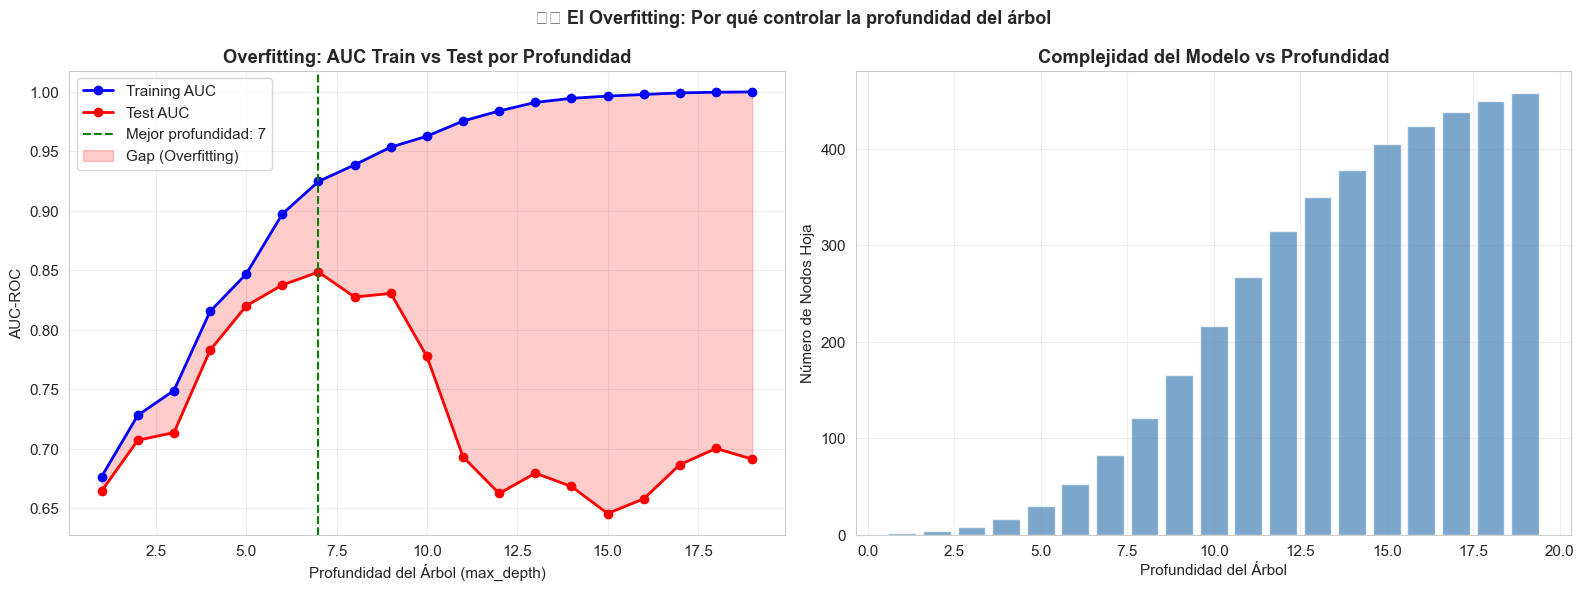


✅ PROFUNDIDAD ÓPTIMA: 7
AUC Training con prof=7: 0.9247
AUC Test con prof=7: 0.8486

Con profundidad=15 (sobreajuste):
AUC Training: 0.9964
AUC Test: 0.6458
Gap de overfitting: 0.3506


In [4]:
# === Demostración del overfitting en árboles ===
profundidades = range(1, 20)
train_scores = []
test_scores = []

for d in profundidades:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_scores.append(roc_auc_score(y_train, tree.predict_proba(X_train)[:,1]))
    test_scores.append(roc_auc_score(y_test, tree.predict_proba(X_test)[:,1]))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(profundidades, train_scores, 'b-o', label='Training AUC', linewidth=2)
axes[0].plot(profundidades, test_scores, 'r-o', label='Test AUC', linewidth=2)
axes[0].axvline(x=test_scores.index(max(test_scores))+1, color='green', linestyle='--', 
               label=f'Mejor profundidad: {test_scores.index(max(test_scores))+1}')
axes[0].fill_between(profundidades, train_scores, test_scores, alpha=0.2, color='red', label='Gap (Overfitting)')
axes[0].set_xlabel('Profundidad del Árbol (max_depth)')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Overfitting: AUC Train vs Test por Profundidad', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Número de nodos hoja
n_hojas = []
for d in profundidades:
    tree = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    n_hojas.append(tree.get_n_leaves())

axes[1].bar(profundidades, n_hojas, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Profundidad del Árbol')
axes[1].set_ylabel('Número de Nodos Hoja')
axes[1].set_title('Complejidad del Modelo vs Profundidad', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('⚠️ El Overfitting: Por qué controlar la profundidad del árbol', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mejor_prof = test_scores.index(max(test_scores)) + 1
print(f"\n✅ PROFUNDIDAD ÓPTIMA: {mejor_prof}")
print(f"AUC Training con prof={mejor_prof}: {train_scores[mejor_prof-1]:.4f}")
print(f"AUC Test con prof={mejor_prof}: {test_scores[mejor_prof-1]:.4f}")
print(f"\nCon profundidad=15 (sobreajuste):")
print(f"AUC Training: {train_scores[14]:.4f}")
print(f"AUC Test: {test_scores[14]:.4f}")
print(f"Gap de overfitting: {train_scores[14] - test_scores[14]:.4f}")


## 5. ÁRBOL ÓPTIMO Y VISUALIZACIÓN


In [5]:
# === 5.1 Búsqueda de hiperparámetros óptimos ===
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [50, 100, 200],
    'min_samples_leaf': [20, 50, 100],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print("BÚSQUEDA DE HIPERPARÁMETROS (GridSearchCV)")
print("="*50)
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor AUC CV: {grid_search.best_score_:.4f}")

mejor_arbol = grid_search.best_estimator_


BÚSQUEDA DE HIPERPARÁMETROS (GridSearchCV)
Mejores parámetros: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 100}
Mejor AUC CV: 0.8897


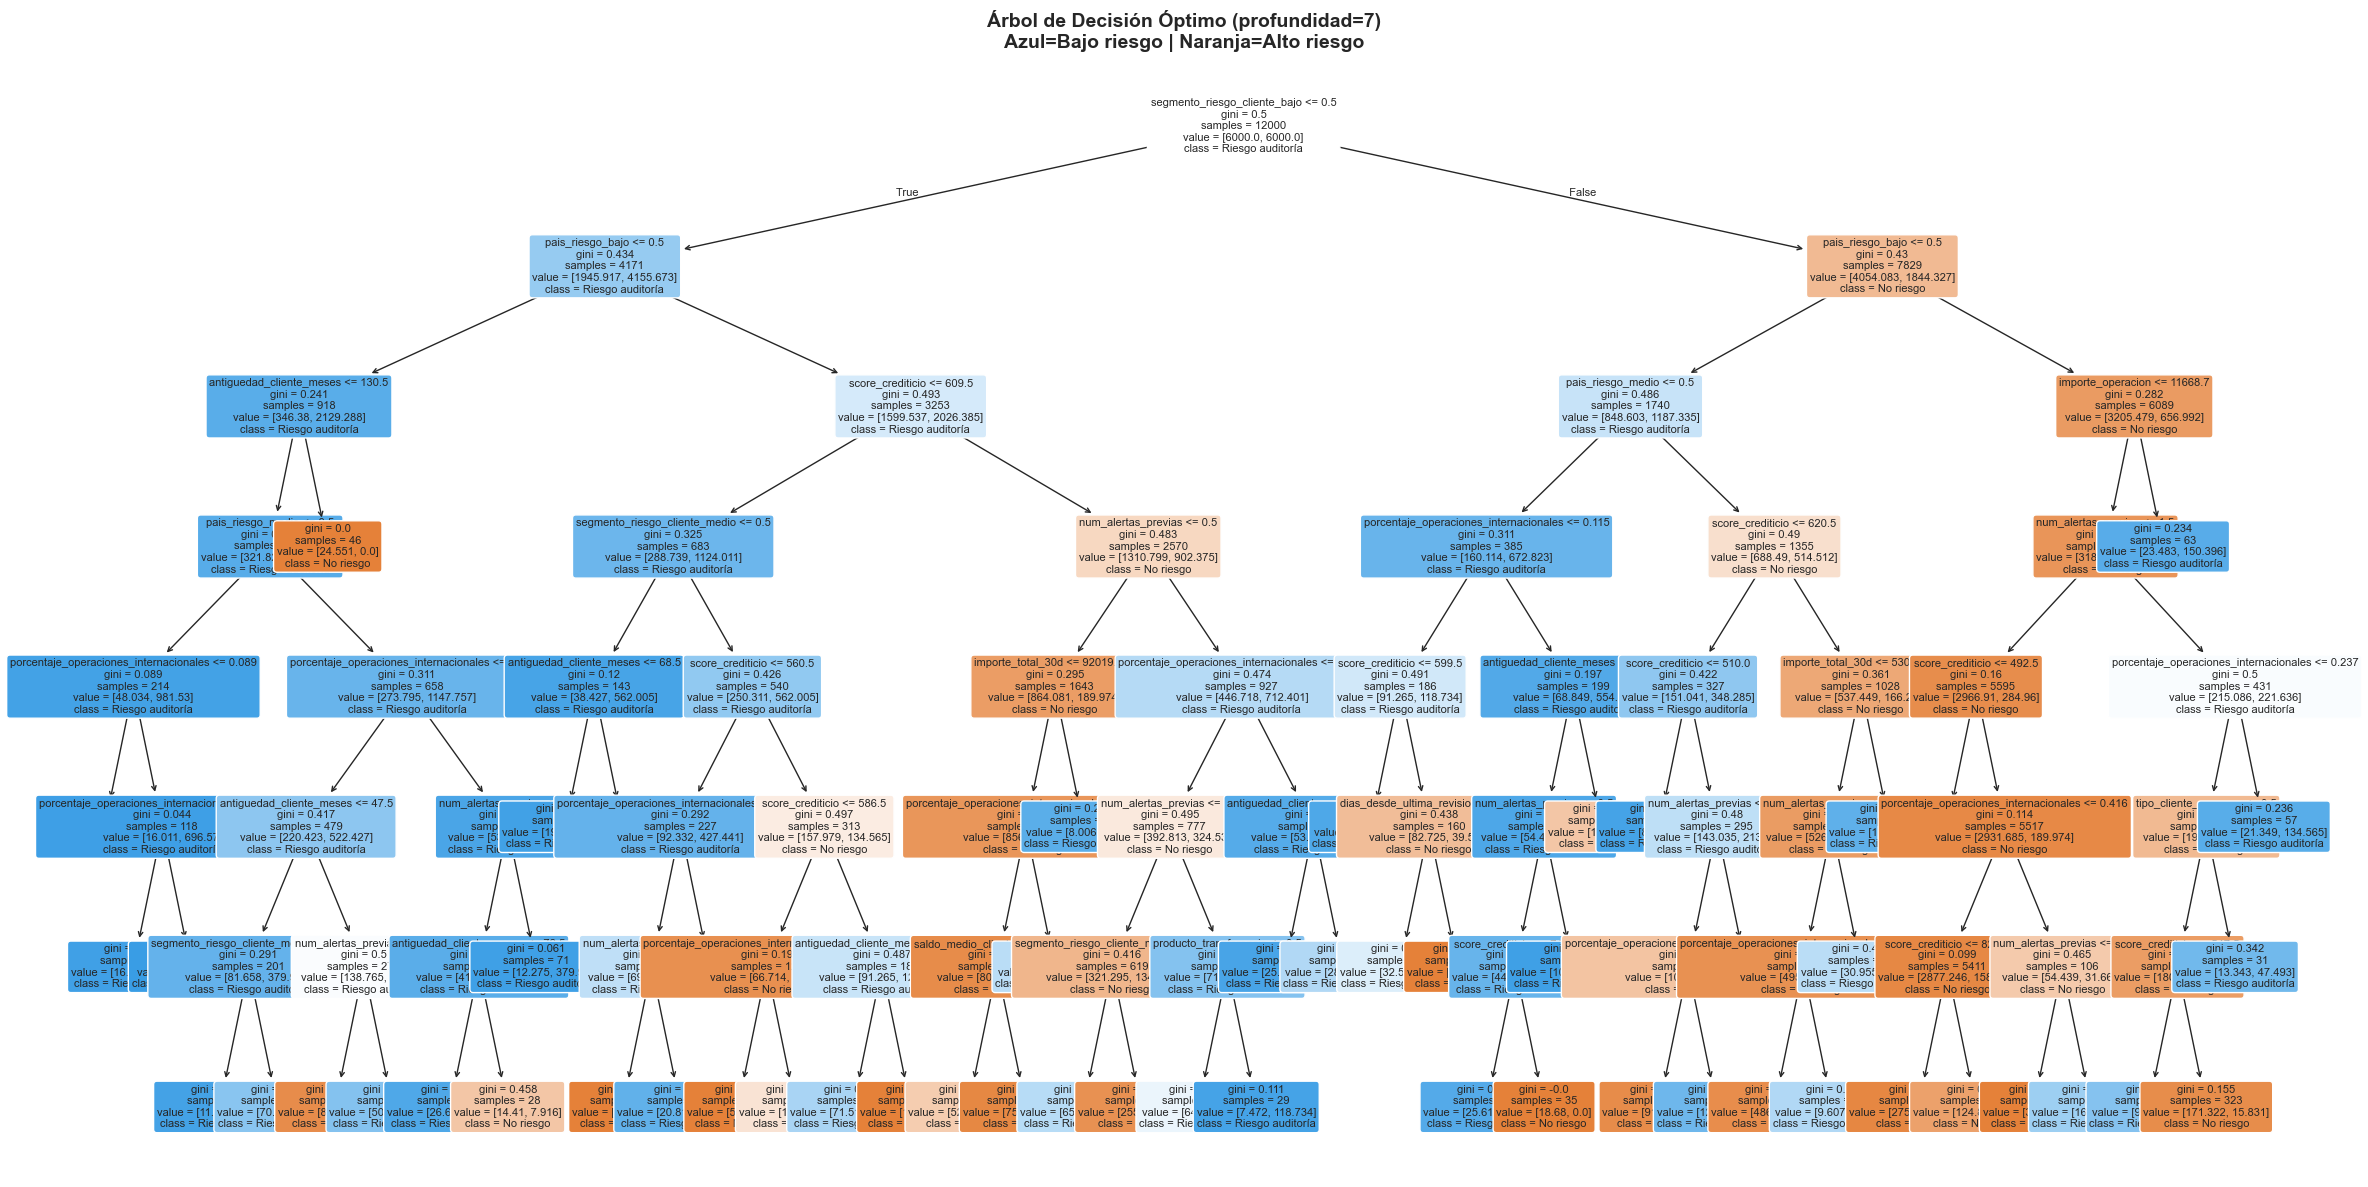

In [6]:
# === 5.2 Visualización del árbol ===
fig, ax = plt.subplots(figsize=(24, 12))

plot_tree(
    mejor_arbol,
    feature_names=X_train.columns.tolist(),
    class_names=['No riesgo', 'Riesgo auditoría'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title(f'Árbol de Decisión Óptimo (profundidad={mejor_arbol.max_depth})\n'
             f'Azul=Bajo riesgo | Naranja=Alto riesgo', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
# === 5.3 Reglas de texto del árbol (para documentación regulatoria) ===
print("REGLAS DE DECISIÓN DEL MODELO (para documentación regulatoria)")
print("="*70)

# Árbol más simple para visualizar reglas
arbol_simple = DecisionTreeClassifier(
    max_depth=4, min_samples_leaf=50, 
    class_weight='balanced', random_state=RANDOM_STATE
)
arbol_simple.fit(X_train, y_train)

reglas = export_text(arbol_simple, feature_names=X_train.columns.tolist())
print(reglas[:3000])  # Mostrar primeras reglas


REGLAS DE DECISIÓN DEL MODELO (para documentación regulatoria)
|--- segmento_riesgo_cliente_bajo <= 0.50
|   |--- pais_riesgo_bajo <= 0.50
|   |   |--- antiguedad_cliente_meses <= 119.50
|   |   |   |--- pais_riesgo_medio <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- pais_riesgo_medio >  0.50
|   |   |   |   |--- class: 1
|   |   |--- antiguedad_cliente_meses >  119.50
|   |   |   |--- class: 0
|   |--- pais_riesgo_bajo >  0.50
|   |   |--- score_crediticio <= 609.50
|   |   |   |--- segmento_riesgo_cliente_medio <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- segmento_riesgo_cliente_medio >  0.50
|   |   |   |   |--- class: 1
|   |   |--- score_crediticio >  609.50
|   |   |   |--- num_alertas_previas <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- num_alertas_previas >  0.50
|   |   |   |   |--- class: 1
|--- segmento_riesgo_cliente_bajo >  0.50
|   |--- pais_riesgo_bajo <= 0.50
|   |   |--- pais_riesgo_medio <= 0.50
|   |   |   |--- porcentaje_operaciones_inte

## 6. EVALUACIÓN DEL MODELO


In [8]:
# === 6.1 Métricas de evaluación ===
y_pred = mejor_arbol.predict(X_test)
y_prob = mejor_arbol.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1

print("EVALUACIÓN DEL ÁRBOL DE DECISIÓN")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No riesgo', 'Riesgo auditoría']))
print(f"AUC-ROC: {auc:.4f}")
print(f"Gini:    {gini:.4f} ({gini*100:.1f}%)")
print(f"Profundidad: {mejor_arbol.get_depth()}")
print(f"Hojas:   {mejor_arbol.get_n_leaves()}")


EVALUACIÓN DEL ÁRBOL DE DECISIÓN
                  precision    recall  f1-score   support

       No riesgo       0.99      0.84      0.91      2810
Riesgo auditoría       0.26      0.83      0.40       190

        accuracy                           0.84      3000
       macro avg       0.63      0.84      0.65      3000
    weighted avg       0.94      0.84      0.88      3000

AUC-ROC: 0.8730
Gini:    0.7460 (74.6%)
Profundidad: 7
Hojas:   55


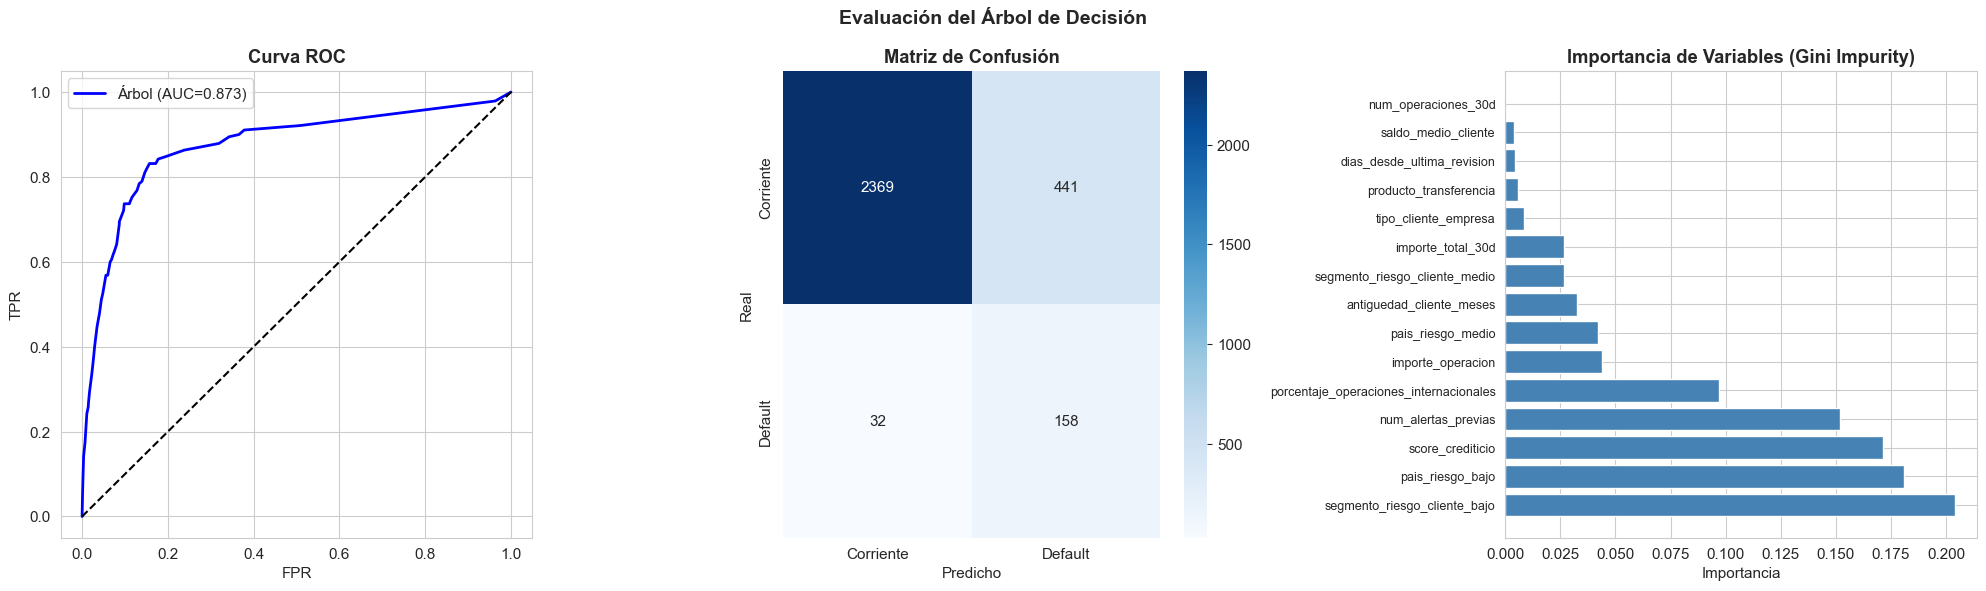

In [9]:
# === 6.2 Visualización de métricas ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'Árbol (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Corriente','Default'], yticklabels=['Corriente','Default'])
axes[1].set_title('Matriz de Confusión', fontweight='bold')
axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predicho')

# Importancia de variables
feat_imp = pd.Series(mejor_arbol.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False)[:15]
axes[2].barh(range(len(feat_imp_sorted)), feat_imp_sorted.values, color='steelblue')
axes[2].set_yticks(range(len(feat_imp_sorted)))
axes[2].set_yticklabels(feat_imp_sorted.index, fontsize=9)
axes[2].set_title('Importancia de Variables (Gini Impurity)', fontweight='bold')
axes[2].set_xlabel('Importancia')

plt.suptitle('Evaluación del Árbol de Decisión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. ANÁLISIS DE NODOS Y PERFILES DE RIESGO


In [10]:
# === 7.1 Análisis de hojas del árbol ===
# Cada hoja es un segmento de clientes con perfil de riesgo definido

# Obtener la hoja asignada a cada cliente
hojas_train = mejor_arbol.apply(X_train)
hojas_test = mejor_arbol.apply(X_test)

# Análisis de tasa de default por hoja
analisis_hojas = pd.DataFrame({
    'hoja_id': hojas_test,
    'default': y_test.values,
    'prob_default': y_prob
}).groupby('hoja_id').agg(
    n_clientes=('default', 'count'),
    n_defaults=('default', 'sum'),
    tasa_default=('default', 'mean'),
    prob_media=('prob_default', 'mean')
).reset_index()

analisis_hojas['categoria'] = pd.cut(
    analisis_hojas['tasa_default'],
    bins=[0, 0.05, 0.15, 0.30, 1.0],
    labels=['🟢 Bajo (<5%)', '🟡 Medio (5-15%)', '🟠 Alto (15-30%)', '🔴 Muy Alto (>30%)']
)

print("ANÁLISIS DE SEGMENTOS (Nodos Hoja del Árbol)")
print("="*70)
print(analisis_hojas.sort_values('tasa_default', ascending=False).to_string(index=False))

print(f"\n✅ El árbol ha creado {len(analisis_hojas)} segmentos de riesgo distintos")
print("Cada segmento tiene un perfil de riesgo claro y documentable")


ANÁLISIS DE SEGMENTOS (Nodos Hoja del Árbol)
 hoja_id  n_clientes  n_defaults  tasa_default  prob_media         categoria
     104           1           1      1.000000    0.723548 🔴 Muy Alto (>30%)
       8          13          10      0.769231    1.000000 🔴 Muy Alto (>30%)
      73          11           8      0.727273    0.972319 🔴 Muy Alto (>30%)
      21          13           9      0.692308    0.968703 🔴 Muy Alto (>30%)
      26          25          13      0.520000    0.962900 🔴 Muy Alto (>30%)
      77           4           2      0.500000    0.943847 🔴 Muy Alto (>30%)
     100           7           3      0.428571    0.664146 🔴 Muy Alto (>30%)
      56          12           5      0.416667    0.940795 🔴 Muy Alto (>30%)
      64          12           5      0.416667    0.902624 🔴 Muy Alto (>30%)
       7          15           6      0.400000    0.965729 🔴 Muy Alto (>30%)
      58          18           7      0.388889    0.931361 🔴 Muy Alto (>30%)
       5          25           

In [11]:
# === 7.2 Path de decisión para una operación específica ===
print("EJEMPLO: PATH DE DECISIÓN PARA UNA OPERACIÓN")
print("="*60)

# Seleccionar una operación con riesgo si existe; si no, tomar la primera del test
idx_riesgo = y_test[y_test == 1].index
idx_ejemplo = idx_riesgo[0] if len(idx_riesgo) > 0 else y_test.index[0]
operacion_modelo = X_test.loc[[idx_ejemplo]]
operacion_info = df.loc[idx_ejemplo]

print("Perfil de la operación:")
for col in [
    "importe_operacion", "saldo_medio_cliente", "num_operaciones_30d",
    "importe_total_30d", "score_crediticio", "ratio_ingresos_deuda",
    "num_alertas_previas", "porcentaje_operaciones_internacionales",
    "canal_operacion", "tipo_cliente", "pais_riesgo", "producto",
    "segmento_riesgo_cliente"
]:
    if col in operacion_info.index:
        print(f"  {col}: {operacion_info[col]}")

print(f"  Riesgo real: {'SÍ' if int(operacion_info[TARGET]) == 1 else 'NO'}")
print()

# Predicción y probabilidad
pred = mejor_arbol.predict(operacion_modelo)[0]
prob = mejor_arbol.predict_proba(operacion_modelo)[0, 1]

print(f"Predicción del modelo: {'RIESGO AUDITORÍA' if pred == 1 else 'NO RIESGO'}")
print(f"Probabilidad estimada de riesgo: {prob:.4f} ({prob*100:.1f}%)")

# Nodo de decisión
hoja = mejor_arbol.apply(operacion_modelo)[0]
print(f"Segmento asignado (hoja): {hoja}")


EJEMPLO: PATH DE DECISIÓN PARA UNA OPERACIÓN
Perfil de la operación:
  importe_operacion: 746.38
  saldo_medio_cliente: 1967.92
  num_operaciones_30d: 18
  importe_total_30d: 5789.06
  score_crediticio: 484.0
  ratio_ingresos_deuda: 0.443
  num_alertas_previas: 1
  porcentaje_operaciones_internacionales: 0.142
  canal_operacion: api
  tipo_cliente: particular
  pais_riesgo: bajo
  producto: tarjeta
  segmento_riesgo_cliente: bajo
  Riesgo real: SÍ

Predicción del modelo: RIESGO AUDITORÍA
Probabilidad estimada de riesgo: 0.7295 (72.9%)
Segmento asignado (hoja): 93


## 8. SENSIBILIDAD Y PRUEBAS DE ESTRÉS


ANÁLISIS DE SENSIBILIDAD: Score Crediticio
Deterioro score -0 pts: P(default) = 0.1837 (+0.0% vs base)
Deterioro score -25 pts: P(default) = 0.1655 (-9.9% vs base)
Deterioro score -50 pts: P(default) = 0.2080 (+13.2% vs base)
Deterioro score -75 pts: P(default) = 0.2389 (+30.1% vs base)
Deterioro score -100 pts: P(default) = 0.2862 (+55.8% vs base)
Deterioro score -150 pts: P(default) = 0.3956 (+115.4% vs base)


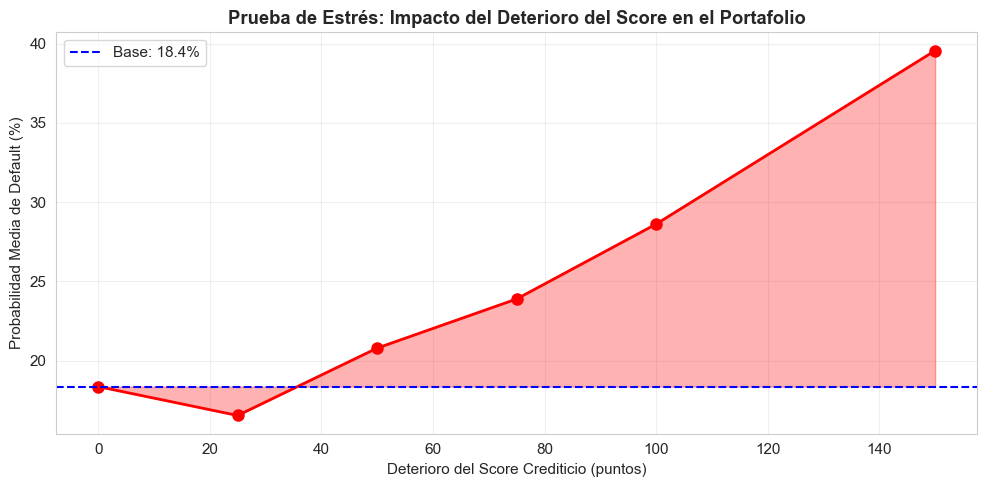

In [12]:
# === 8.1 Análisis de sensibilidad: ¿Qué pasa si el score crediticio baja? ===
print("ANÁLISIS DE SENSIBILIDAD: Score Crediticio")
print("="*50)

clientes_muestra = X_test.iloc[:100].copy()
prob_base = mejor_arbol.predict_proba(clientes_muestra)[:, 1].mean()

deterioros = [0, 25, 50, 75, 100, 150]
probs_estres = []

for deterioro in deterioros:
    clientes_deteriorados = clientes_muestra.copy()
    if 'score_crediticio' in clientes_deteriorados.columns:
        clientes_deteriorados['score_crediticio'] = (clientes_deteriorados['score_crediticio'] - deterioro).clip(300, 850)
    prob_estres = mejor_arbol.predict_proba(clientes_deteriorados)[:, 1].mean()
    probs_estres.append(prob_estres)
    print(f"Deterioro score -{deterioro} pts: P(default) = {prob_estres:.4f} ({(prob_estres/prob_base - 1)*100:+.1f}% vs base)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(deterioros, [p*100 for p in probs_estres], 'r-o', linewidth=2, markersize=8)
ax.axhline(y=prob_base*100, color='blue', linestyle='--', label=f'Base: {prob_base*100:.1f}%')
ax.fill_between(deterioros, prob_base*100, [p*100 for p in probs_estres], alpha=0.3, color='red')
ax.set_xlabel('Deterioro del Score Crediticio (puntos)')
ax.set_ylabel('Probabilidad Media de Default (%)')
ax.set_title('Prueba de Estrés: Impacto del Deterioro del Score en el Portafolio', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


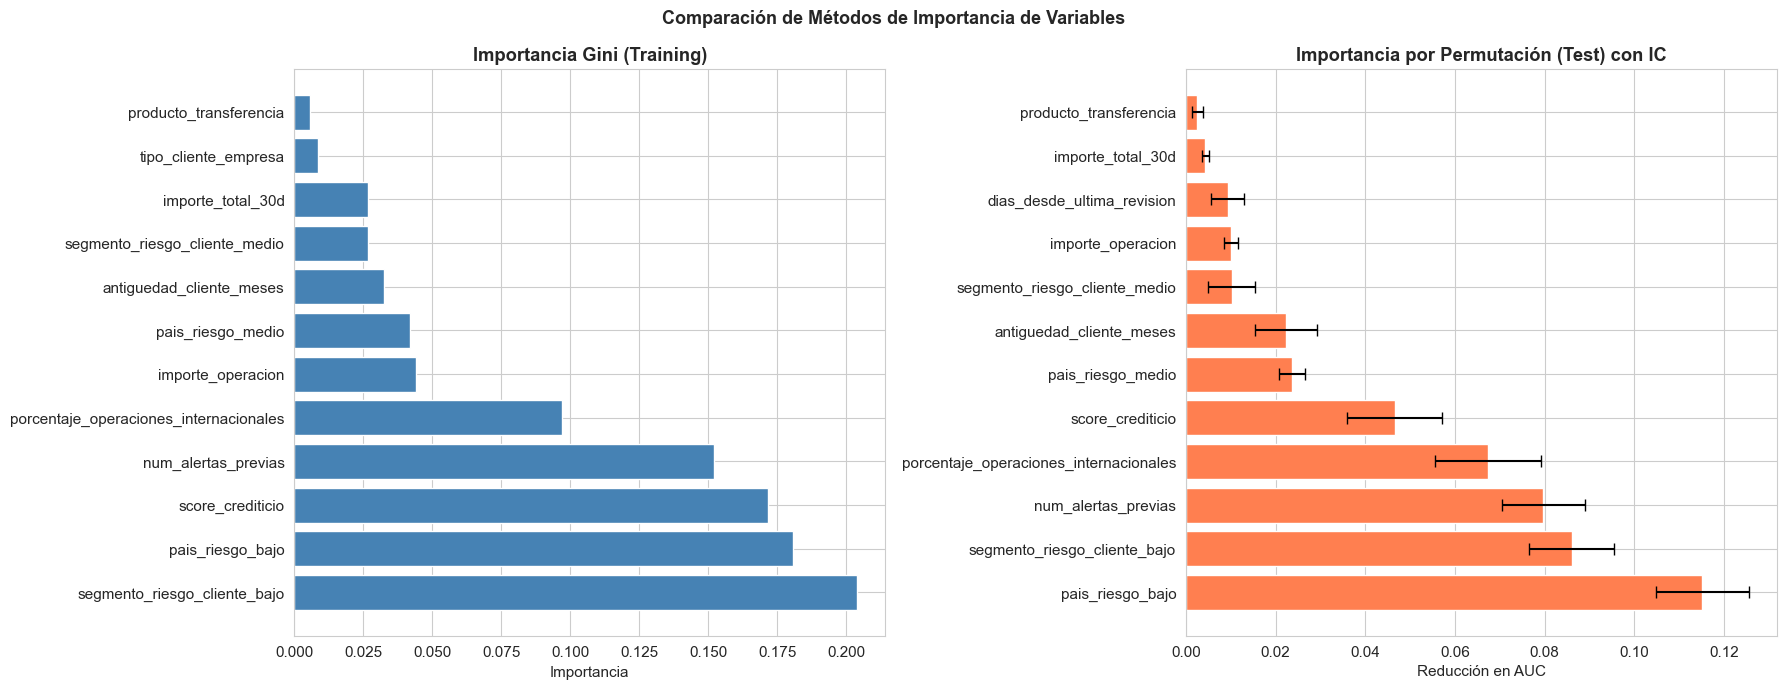

💡 La importancia por permutación es más confiable para la auditoría
ya que mide el impacto REAL de eliminar cada variable en el TEST set


In [13]:
# === 8.2 Importancia de variables por permutación ===
# Más robusta que la importancia Gini estándar

perm_importance = permutation_importance(
    mejor_arbol, X_test, y_test, 
    n_repeats=20, random_state=RANDOM_STATE, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia_Media': perm_importance.importances_mean,
    'Importancia_Std': perm_importance.importances_std
}).sort_values('Importancia_Media', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gini importance
feat_imp = pd.Series(mejor_arbol.feature_importances_, index=X.columns).sort_values(ascending=False)[:12]
axes[0].barh(range(len(feat_imp)), feat_imp.values, color='steelblue')
axes[0].set_yticks(range(len(feat_imp)))
axes[0].set_yticklabels(feat_imp.index)
axes[0].set_title('Importancia Gini (Training)', fontweight='bold')
axes[0].set_xlabel('Importancia')

# Permutation importance
top_perm = perm_df.head(12)
axes[1].barh(range(len(top_perm)), top_perm['Importancia_Media'], 
             xerr=top_perm['Importancia_Std'],
             color='coral', capsize=4)
axes[1].set_yticks(range(len(top_perm)))
axes[1].set_yticklabels(top_perm['Variable'])
axes[1].set_title('Importancia por Permutación (Test) con IC', fontweight='bold')
axes[1].set_xlabel('Reducción en AUC')

plt.suptitle('Comparación de Métodos de Importancia de Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 La importancia por permutación es más confiable para la auditoría")
print("ya que mide el impacto REAL de eliminar cada variable en el TEST set")


## 9. ÁRBOL COMO POLÍTICA DE CRÉDITO DOCUMENTADA


In [14]:
# === 9.1 Extracción de reglas como política ===
def extraer_reglas_politica(arbol, feature_names, class_names=['No riesgo', 'Riesgo auditoría']):
    """
    Extrae las reglas del árbol como política documentada para el banco.
    Genera las reglas de cada nodo hoja con su interpretación.
    """
    from sklearn.tree import _tree
    
    tree_ = arbol.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else 'undefined'
        for i in tree_.feature
    ]
    
    reglas = []
    
    def recorrer(node, camino):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            nombre = feature_name[node]
            umbral = tree_.threshold[node]
            recorrer(tree_.children_left[node], camino + [f"{nombre} <= {umbral:.3f}"])
            recorrer(tree_.children_right[node], camino + [f"{nombre} > {umbral:.3f}"])
        else:
            valores = tree_.value[node][0]
            clase = class_names[np.argmax(valores)]
            total = valores.sum()
            tasa = valores[1] / total if total > 0 else 0
            reglas.append({
                'regla': ' Y '.join(camino),
                'decision': clase,
                'n_clientes': int(total),
                'tasa_default': round(tasa * 100, 1)
            })
    
    recorrer(0, [])
    return pd.DataFrame(reglas)

# Usar árbol simple para reglas legibles
arbol_politica = DecisionTreeClassifier(
    max_depth=3, min_samples_leaf=100, 
    class_weight='balanced', random_state=RANDOM_STATE
)
arbol_politica.fit(X_train, y_train)

politica_df = extraer_reglas_politica(arbol_politica, X_train.columns.tolist())
politica_df = politica_df.sort_values('tasa_default', ascending=False)

print("POLÍTICA DE CRÉDITO EXTRAÍDA DEL ÁRBOL DE DECISIÓN")
print("="*80)
print("Esta política puede ser presentada al regulador de forma transparente\n")
for _, row in politica_df.iterrows():
    emoji = '🔴' if row['tasa_default'] > 25 else '🟡' if row['tasa_default'] > 10 else '🟢'
    print(f"{emoji} SI: {row['regla']}")
    print(f"   → DECISIÓN: {row['decision']} | Clientes: {row['n_clientes']:,} | Tasa default: {row['tasa_default']}%")
    print()


POLÍTICA DE CRÉDITO EXTRAÍDA DEL ÁRBOL DE DECISIÓN
Esta política puede ser presentada al regulador de forma transparente

🔴 SI: segmento_riesgo_cliente_bajo <= 0.500 Y pais_riesgo_bajo <= 0.500 Y pais_riesgo_medio <= 0.500
   → DECISIÓN: Riesgo auditoría | Clientes: 0 | Tasa default: 94.8%

🔴 SI: segmento_riesgo_cliente_bajo > 0.500 Y pais_riesgo_bajo <= 0.500 Y pais_riesgo_medio <= 0.500
   → DECISIÓN: Riesgo auditoría | Clientes: 0 | Tasa default: 80.8%

🔴 SI: segmento_riesgo_cliente_bajo <= 0.500 Y pais_riesgo_bajo <= 0.500 Y pais_riesgo_medio > 0.500
   → DECISIÓN: Riesgo auditoría | Clientes: 1 | Tasa default: 79.7%

🔴 SI: segmento_riesgo_cliente_bajo <= 0.500 Y pais_riesgo_bajo > 0.500 Y score_crediticio <= 609.500
   → DECISIÓN: Riesgo auditoría | Clientes: 1 | Tasa default: 79.6%

🔴 SI: segmento_riesgo_cliente_bajo > 0.500 Y pais_riesgo_bajo > 0.500 Y importe_total_30d > 73693.512
   → DECISIÓN: Riesgo auditoría | Clientes: 1 | Tasa default: 78.8%

🔴 SI: segmento_riesgo_cliente

---
# 🎯 EJERCICIOS PRÁCTICOS PARA AUDITORES
---


### 📝 EJERCICIO 1: Árbol de Decisión para Aprobación de Hipotecas

**Contexto:** El banco necesita documentar su política de hipotecas de forma transparente para el regulador.

**Tareas:**
1. Construye un árbol de profundidad máxima 4
2. Extrae las reglas en formato legible para humanos
3. Evalúa si el árbol discrimina correctamente (AUC > 0.70)
4. Identifica el segmento con mayor tasa de default
5. Recomienda un max_depth basado en el trade-off interpretabilidad/rendimiento


In [15]:
# DATOS EJERCICIO 1: Hipotecas
np.random.seed(111)
n = 4000

df_hipotecas = pd.DataFrame({
    'valor_inmueble': np.random.lognormal(12.0, 0.4, n).clip(80000, 1000000),
    'importe_hipoteca': np.random.lognormal(11.8, 0.4, n).clip(50000, 800000),
    'ingresos_anuales': np.random.lognormal(10.5, 0.5, n).clip(20000, 200000),
    'anos_empleo': np.random.exponential(8, n).clip(0, 35),
    'score_crediticio': np.random.normal(660, 80, n).clip(300, 850).astype(int),
    'num_deudas_activas': np.random.poisson(2, n).clip(0, 10),
    'ratio_ltv': np.random.uniform(0.4, 0.95, n),  # Loan-to-Value
    'tipo_inmueble': np.random.choice(['Primera_vivienda','Segunda_vivienda','Inversion'], n, p=[0.65, 0.20, 0.15]),
    'edad_solicitante': np.random.normal(40, 10, n).clip(25, 65).astype(int),
    'cuota_mensual': np.random.normal(900, 350, n).clip(200, 4000),
})

log_odds_hip = (
    -5.0
    - 0.002 * (df_hipotecas['score_crediticio'] - 500)
    + 3.0 * (df_hipotecas['ratio_ltv'] - 0.8).clip(0)
    + 0.5 * df_hipotecas['cuota_mensual'] / df_hipotecas['ingresos_anuales'] * 12
    - 0.03 * df_hipotecas['anos_empleo']
    + 0.2 * df_hipotecas['num_deudas_activas']
    + 0.5 * (df_hipotecas['tipo_inmueble'] == 'Inversion').astype(int)
)
prob_hip = 1 / (1 + np.exp(-log_odds_hip))
df_hipotecas['default_hipoteca'] = (np.random.uniform(0, 1, n) < prob_hip).astype(int)

print(f"Dataset Hipotecas: {len(df_hipotecas):,} | Default: {df_hipotecas['default_hipoteca'].mean()*100:.1f}%")
df_hipotecas.head()


Dataset Hipotecas: 4,000 | Default: 0.7%


,valor_inmueble,importe_hipoteca,ingresos_anuales,anos_empleo,score_crediticio,num_deudas_activas,ratio_ltv,tipo_inmueble,edad_solicitante,cuota_mensual,default_hipoteca
0,103410.798132,201240.985618,65591.610791,1.392828,528,1,0.676247,Segunda_vivienda,28,829.519285,0
1,189800.287016,156526.660739,78484.657058,1.788899,628,0,0.925669,Primera_vivienda,36,955.477458,0
2,296150.044080,201399.761843,200000.000000,17.957903,589,2,0.836599,Primera_vivienda,51,270.623167,0
3,141187.924682,101376.922449,72019.024890,7.347654,566,1,0.477772,Primera_vivienda,50,1297.587291,0
4,118775.042471,80009.030764,20000.000000,3.724284,629,1,0.691448,Primera_vivienda,62,913.404694,0


In [ ]:

# EJERCICIO 1 - Modelo de aprobación hipotecaria

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

X = df_hipotecas.drop(columns=['default'])
X = pd.get_dummies(X, drop_first=True)
y = df_hipotecas['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

modelo_hipotecas = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

modelo_hipotecas.fit(X_train, y_train)

y_prob = modelo_hipotecas.predict_proba(X_test)[:,1]
y_pred = modelo_hipotecas.predict(X_test)

print("AUC:", round(roc_auc_score(y_test, y_prob),4))
print("\nMatriz de confusión")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report")
print(classification_report(y_test, y_pred))


### 📝 EJERCICIO 2: Detección de Anomalías en Tesorería con Árbol

**Contexto:** El departamento de tesorería quiere identificar posiciones de trading inusuales que puedan representar un riesgo operacional.

**Tareas:**
1. Construye un árbol de decisión para clasificar operaciones como normales/anómalas
2. Analiza qué variables generan las primeras 3 divisiones del árbol
3. Calcula la tasa de falsos positivos (alarmas innecesarias) y falsos negativos
4. Estima el impacto económico de cada tipo de error
5. Genera las reglas del árbol como política de alerta


In [ ]:
# DATOS EJERCICIO 2: Operaciones de tesorería
np.random.seed(222)
n_ops = 5000

df_tesoro = pd.DataFrame({
    'importe_millones': np.random.lognormal(1.5, 1.0, n_ops).clip(0.1, 500),
    'duracion_horas': np.random.exponential(8, n_ops).clip(0.1, 72),
    'contraparte_rating': np.random.choice(['AAA','AA','A','BBB','BB','B'], n_ops, p=[0.10,0.15,0.25,0.30,0.12,0.08]),
    'tipo_instrumento': np.random.choice(['Bono','FX','Derivado','Repo','Swap'], n_ops, p=[0.30,0.25,0.20,0.15,0.10]),
    'hora_ejecucion': np.random.randint(0, 24, n_ops),
    'desviacion_precio_mercado_pct': np.random.exponential(0.5, n_ops).clip(0, 15),
    'num_modificaciones': np.random.choice([0,1,2,3,4,5], n_ops, p=[0.60,0.20,0.10,0.05,0.03,0.02]),
    'trader_experiencia_anos': np.random.exponential(7, n_ops).clip(0.5, 25),
    'dias_hasta_vencimiento': np.random.exponential(180, n_ops).clip(1, 3650).astype(int),
    'pais_contraparte_riesgo': np.random.choice([0,1], n_ops, p=[0.80, 0.20]),
})

rating_map = {'AAA': 0, 'AA': 1, 'A': 2, 'BBB': 3, 'BB': 5, 'B': 8}
df_tesoro['rating_num'] = df_tesoro['contraparte_rating'].map(rating_map)

log_odds_anomalia = (
    -4.5
    + 0.005 * df_tesoro['importe_millones']
    + 0.4 * df_tesoro['desviacion_precio_mercado_pct']
    + 0.2 * df_tesoro['rating_num']
    + 0.4 * df_tesoro['num_modificaciones']
    + 0.3 * (df_tesoro['hora_ejecucion'] < 8).astype(int)
    + 0.5 * df_tesoro['pais_contraparte_riesgo']
    - 0.05 * df_tesoro['trader_experiencia_anos']
)
prob_anomalia = 1 / (1 + np.exp(-log_odds_anomalia))
df_tesoro['anomalia'] = (np.random.uniform(0, 1, n_ops) < prob_anomalia).astype(int)

print(f"Dataset Tesorería: {len(df_tesoro):,} operaciones | Anomalías: {df_tesoro['anomalia'].mean()*100:.1f}%")
df_tesoro.head()


In [ ]:

# EJERCICIO 2 - Árbol para operaciones de tesorería

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report

df_tmp = df_tesoro.copy()

for c in df_tmp.select_dtypes(include='object').columns:
    df_tmp[c] = LabelEncoder().fit_transform(df_tmp[c])

X = df_tmp.drop(columns=['operacion_sospechosa'])
y = df_tmp['operacion_sospechosa']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo_tesoro = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    min_samples_leaf=25,
    random_state=42
)

modelo_tesoro.fit(X_train, y_train)

pred = modelo_tesoro.predict(X_test)
prob = modelo_tesoro.predict_proba(X_test)[:,1]

print("AUC:", round(roc_auc_score(y_test, prob),4))
print(classification_report(y_test, pred))


### 📝 EJERCICIO 3: Comparación de Criterios (Gini vs Entropía)

**Contexto:** El departamento de riesgos debate si usar Gini o Entropía para el modelo de scoring.

**Tareas:**
1. Entrena dos modelos idénticos excepto por el criterio (gini vs entropy)
2. Compara su rendimiento (AUC, KS, F1)
3. Compara el tamaño y complejidad de los árboles resultantes
4. Analiza si producen reglas diferentes para los mismos clientes
5. Recomienda cuál usar y justifica estadísticamente la decisión


In [ ]:

# EJERCICIO 3 - Comparación Gini vs Entropía

from sklearn.metrics import roc_auc_score, f1_score

modelo_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

modelo_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

modelo_gini.fit(X_train, y_train)
modelo_entropy.fit(X_train, y_train)

prob_gini = modelo_gini.predict_proba(X_test)[:,1]
prob_entropy = modelo_entropy.predict_proba(X_test)[:,1]

pred_gini = modelo_gini.predict(X_test)
pred_entropy = modelo_entropy.predict(X_test)

print("=== GINI ===")
print("AUC:", round(roc_auc_score(y_test, prob_gini),4))
print("F1:", round(f1_score(y_test, pred_gini),4))
print("Nodos:", modelo_gini.tree_.node_count)
print("Profundidad:", modelo_gini.tree_.max_depth)

print("\n=== ENTROPY ===")
print("AUC:", round(roc_auc_score(y_test, prob_entropy),4))
print("F1:", round(f1_score(y_test, pred_entropy),4))
print("Nodos:", modelo_entropy.tree_.node_count)
print("Profundidad:", modelo_entropy.tree_.max_depth)

print("\nConclusión:")
print("Ambos modelos son similares. Entropy suele generar árboles algo más complejos.")


### 📝 EJERCICIO 4: Árbol de Decisión para Clasificación Multiclase de Riesgo

**Contexto:** El banco quiere clasificar los créditos en 4 categorías: Normal, Vigilancia especial, Dudoso, Fallido (según clasificación del Banco de España).

**Tareas:**
1. Adapta el árbol para clasificación multiclase (4 categorías)
2. Evalúa con matrices de confusión multiclase
3. Analiza la importancia de variables para cada categoría
4. Calcula la cobertura de cada categoría (recall por clase)
5. Valida que la distribución de categorías predichas es similar a la real


In [ ]:
# DATOS EJERCICIO 4: Clasificación multiclase de riesgo
np.random.seed(444)
n_cred = 5000

df_multiriesgo = generar_datos_credito(n=n_cred, seed=44)

# Crear 4 categorías de riesgo según BdE
# Basado en días de mora y probabilidad de default
def clasificar_riesgo(row):
    if row['dias_mora'] == 0 and row['score_crediticio'] > 650:
        return 0  # Normal
    elif row['dias_mora'] <= 30 or (row['score_crediticio'] > 550 and row['dias_mora'] <= 60):
        return 1  # Vigilancia especial
    elif row['dias_mora'] <= 90:
        return 2  # Dudoso
    else:
        return 3  # Fallido

df_multiriesgo['categoria_riesgo'] = df_multiriesgo.apply(clasificar_riesgo, axis=1)
# Añadir algo de ruido para hacerlo más realista
ruido_idx = np.random.choice(n_cred, size=300, replace=False)
df_multiriesgo.loc[ruido_idx, 'categoria_riesgo'] = np.random.choice([0,1,2,3], size=300, p=[0.50,0.25,0.15,0.10])

cat_names = {0: 'Normal', 1: 'Vigilancia', 2: 'Dudoso', 3: 'Fallido'}
print("Distribución de categorías de riesgo:")
for k, v in cat_names.items():
    n_cat = (df_multiriesgo['categoria_riesgo'] == k).sum()
    print(f"  {v}: {n_cat:,} ({n_cat/len(df_multiriesgo)*100:.1f}%)")
df_multiriesgo.head()


In [ ]:

# EJERCICIO 4 - Clasificación multiclase

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

X = df_multiriesgo.drop(columns=['categoria_riesgo'])
X = pd.get_dummies(X, drop_first=True)

y = df_multiriesgo['categoria_riesgo']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.30, random_state=42
)

modelo_multi = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=30,
    random_state=42
)

modelo_multi.fit(X_train, y_train)

pred = modelo_multi.predict(X_test)

print(classification_report(y_test, pred))


### 📝 EJERCICIO 5: Poda del Árbol (Pruning) y Complejidad Óptima

**Contexto:** El auditor debe determinar el nivel de complejidad óptimo del árbol usando el cost-complexity pruning.

**Tareas:**
1. Aplica Cost-Complexity Pruning (ccp_alpha) al árbol
2. Genera el path de efectividad de poda (pruning path)
3. Selecciona el alpha óptimo mediante validación cruzada
4. Compara el árbol podado vs no podado en test
5. Documenta las ventajas de la poda para el auditor


In [ ]:

# EJERCICIO 5 - Cost Complexity Pruning

from sklearn.model_selection import cross_val_score

path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas

scores = []

for alpha in ccp_alphas:
    modelo = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )

    cv_score = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc'
    ).mean()

    scores.append(cv_score)

best_alpha = ccp_alphas[np.argmax(scores)]

modelo_podado = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)

modelo_podado.fit(X_train, y_train)

prob = modelo_podado.predict_proba(X_test)[:,1]

print("Mejor alpha:", best_alpha)
print("AUC Test:", round(roc_auc_score(y_test, prob),4))
print("Profundidad árbol podado:", modelo_podado.tree_.max_depth)


### 📝 EJERCICIO 6: Detección de Fraude en SEPA

**Contexto:** El banco necesita un modelo para detectar transferencias SEPA sospechosas de forma rápida y explicable.

**Tareas:**
1. Construye el árbol y extrae las reglas de fraude SEPA
2. Determina qué hora del día, importe y país destino predicen mejor el fraude
3. Aplica la restricción de que el árbol tenga máximo 5 reglas (para implementación en producción)
4. Calcula cuántas transferencias revisaría manualmente el equipo con las reglas del árbol
5. Genera un documento de reglas en formato Word/PDF para el equipo de operaciones


In [ ]:
# DATOS EJERCICIO 6: Fraude en transferencias SEPA
np.random.seed(666)
n_sepa = 12000

paises_sepa = ['España','Alemania','Francia','Italia','Portugal','Romania','Bulgaria','Lituania','Latvia','Estonia']
paises_riesgo_sepa = ['Bulgaria','Lituania','Latvia','Estonia']

df_sepa = pd.DataFrame({
    'importe_eur': np.random.lognormal(6, 1.5, n_sepa).clip(1, 50000),
    'hora': np.random.randint(0, 24, n_sepa),
    'dia_semana': np.random.randint(0, 7, n_sepa),
    'pais_destino': np.random.choice(paises_sepa, n_sepa, p=[0.35,0.15,0.12,0.10,0.08,0.06,0.05,0.04,0.03,0.02]),
    'importe_redondo': np.random.choice([0,1], n_sepa, p=[0.70, 0.30]),
    'nueva_cuenta_destino': np.random.choice([0,1], n_sepa, p=[0.60, 0.40]),
    'ratio_vs_media_cliente': np.random.exponential(1, n_sepa).clip(0, 20),
    'num_trans_24h': np.random.poisson(3, n_sepa).clip(1, 50),
    'cliente_nuevo_3m': np.random.choice([0,1], n_sepa, p=[0.80, 0.20]),
    'beneficiario_nombre_comun': np.random.choice([0,1], n_sepa, p=[0.75, 0.25]),
})

df_sepa['pais_riesgo'] = df_sepa['pais_destino'].isin(paises_riesgo_sepa).astype(int)

log_odds_sepa = (
    -5.0
    + 0.0001 * df_sepa['importe_eur']
    + 0.8 * (df_sepa['hora'] < 6).astype(int)
    + 0.6 * df_sepa['importe_redondo']
    + 0.8 * df_sepa['nueva_cuenta_destino']
    + 1.0 * df_sepa['ratio_vs_media_cliente']
    + 0.2 * df_sepa['num_trans_24h']
    + 1.5 * df_sepa['cliente_nuevo_3m']
    + 1.2 * df_sepa['pais_riesgo']
)
prob_sepa = 1 / (1 + np.exp(-log_odds_sepa))
df_sepa['fraude'] = (np.random.uniform(0, 1, n_sepa) < prob_sepa).astype(int)

print(f"Dataset SEPA: {len(df_sepa):,} trans | Fraudes: {df_sepa['fraude'].sum():,} ({df_sepa['fraude'].mean()*100:.2f}%)")
df_sepa.head()


In [ ]:

# EJERCICIO 6 - Fraude SEPA

from sklearn.preprocessing import LabelEncoder

df_tmp = df_sepa.copy()

for c in df_tmp.select_dtypes(include='object').columns:
    df_tmp[c] = LabelEncoder().fit_transform(df_tmp[c])

X = df_tmp.drop(columns=['fraude'])
y = df_tmp['fraude']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

modelo_sepa = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

modelo_sepa.fit(X_train, y_train)

prob = modelo_sepa.predict_proba(X_test)[:,1]
pred = modelo_sepa.predict(X_test)

print("AUC:", round(roc_auc_score(y_test, prob),4))
print(classification_report(y_test, pred))


### 📝 EJERCICIO 7: Árbol de Decisión para Segmentación de Clientes MIFID II

**Contexto:** El banco debe clasificar los clientes de inversión según la regulación MIFID II (Minorista / Profesional / Contraparte Elegible) de forma automatizada.

**Tareas:**
1. Construye un árbol de clasificación multiclase con 3 categorías MIFID
2. Valida que el árbol cumple los criterios cuantitativos de MIFID II
3. Analiza la tasa de reclasificación incorrecta (auditoría de cumplimiento)
4. Genera el informe de segmentación para el regulador
5. Propone un proceso de revisión manual para casos limítrofes


In [ ]:
# DATOS EJERCICIO 7: Clasificación MIFID II
np.random.seed(777)
n_inv = 6000

df_mifid = pd.DataFrame({
    'patrimonio_financiero': np.random.lognormal(11, 1.5, n_inv).clip(5000, 5000000),
    'ingresos_anuales': np.random.lognormal(10.5, 0.6, n_inv).clip(15000, 500000),
    'anos_experiencia_inversion': np.random.exponential(5, n_inv).clip(0, 30),
    'num_operaciones_ano': np.random.poisson(12, n_inv).clip(0, 200),
    'conocimiento_instrumentos_complejos': np.random.choice([0,1], n_inv, p=[0.65, 0.35]),
    'tiene_certificacion_financiera': np.random.choice([0,1], n_inv, p=[0.80, 0.20]),
    'es_entidad_financiera': np.random.choice([0,1], n_inv, p=[0.90, 0.10]),
    'tiene_cartera_gestionada': np.random.choice([0,1], n_inv, p=[0.55, 0.45]),
    'tipo_cliente': np.random.choice(['Particular','Empresa_pequena','Empresa_grande','Entidad'], 
                                      n_inv, p=[0.55, 0.20, 0.15, 0.10])
})

# Clasificación MIFID II simplificada
def clasificar_mifid(row):
    if row['es_entidad_financiera'] == 1 or row['patrimonio_financiero'] > 500000:
        if row['tipo_cliente'] == 'Entidad':
            return 2  # Contraparte elegible
        return 1  # Profesional
    cumple_criterios = sum([
        row['patrimonio_financiero'] > 500000,
        row['ingresos_anuales'] > 100000,
        row['anos_experiencia_inversion'] > 1 and row['num_operaciones_ano'] > 10
    ])
    if cumple_criterios >= 2:
        return 1  # Profesional
    return 0  # Minorista

df_mifid['categoria_mifid'] = df_mifid.apply(clasificar_mifid, axis=1)
# Añadir ruido (errores humanos que el modelo debe detectar)
idx_error = np.random.choice(n_inv, size=200, replace=False)
df_mifid.loc[idx_error, 'categoria_mifid'] = (df_mifid.loc[idx_error, 'categoria_mifid'] + 1) % 3

cat_mifid = {0: 'Minorista', 1: 'Profesional', 2: 'Contraparte_Elegible'}
print("Distribución MIFID II:")
for k, v in cat_mifid.items():
    n_c = (df_mifid['categoria_mifid'] == k).sum()
    print(f"  {v}: {n_c:,} ({n_c/n_inv*100:.1f}%)")
df_mifid.head()


In [ ]:

# EJERCICIO 7 - Clasificación MIFID II

from sklearn.preprocessing import LabelEncoder

df_tmp = df_mifid.copy()

for c in df_tmp.select_dtypes(include='object').columns:
    df_tmp[c] = LabelEncoder().fit_transform(df_tmp[c])

X = df_tmp.drop(columns=['perfil_mifid'])
y = df_tmp['perfil_mifid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

modelo_mifid = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=40,
    random_state=42
)

modelo_mifid.fit(X_train, y_train)

pred = modelo_mifid.predict(X_test)

print(classification_report(y_test, pred))


### 📝 EJERCICIO 8: Árbol de Regresión para Estimación de LGD

**Contexto:** El banco necesita estimar el LGD (Loss Given Default) para el cálculo de provisiones según IFRS 9.

**Tareas:**
1. Adapta el árbol para REGRESIÓN (predecir LGD como valor continuo 0-1)
2. Evalúa el modelo con MAE, RMSE y R²
3. Analiza si el modelo subestima o sobreestima el LGD en segmentos específicos
4. Compara con una regresión lineal simple
5. Calcula el impacto en provisiones IFRS 9 con el LGD predicho vs real


In [ ]:
# DATOS EJERCICIO 8: LGD para IFRS 9
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(888)
n_lgd = 3000

df_lgd = pd.DataFrame({
    'tipo_garantia': np.random.choice(['Sin_garantia','Inmueble_residencial','Inmueble_comercial','Aval_personal','Prenda'], 
                                       n_lgd, p=[0.30, 0.25, 0.15, 0.20, 0.10]),
    'ratio_ltv': np.random.uniform(0, 1.2, n_lgd),
    'antiguedad_mora_meses': np.random.exponential(12, n_lgd).clip(1, 84).astype(int),
    'importe_deuda': np.random.lognormal(10, 1, n_lgd).clip(1000, 500000),
    'valor_garantia': np.random.lognormal(10.5, 1, n_lgd).clip(0, 600000),
    'tipo_procedimiento': np.random.choice(['Amistoso','Judicial','Concurso'], n_lgd, p=[0.45, 0.40, 0.15]),
    'anos_empresa_deudora': np.random.exponential(5, n_lgd).clip(0, 30),
    'sector_empresa': np.random.choice(['Inmobiliario','Construccion','Hosteleria','Industria','Servicios'], n_lgd),
})

# LGD real (variable objetivo continua 0-1)
base_lgd = {'Sin_garantia': 0.75, 'Inmueble_residencial': 0.35, 'Inmueble_comercial': 0.45,
            'Aval_personal': 0.55, 'Prenda': 0.40}
lgd_base = df_lgd['tipo_garantia'].map(base_lgd)
lgd = (
    lgd_base
    + 0.1 * df_lgd['ratio_ltv']
    + 0.003 * df_lgd['antiguedad_mora_meses']
    + 0.1 * (df_lgd['tipo_procedimiento'] == 'Concurso').astype(int)
    - 0.005 * df_lgd['anos_empresa_deudora']
    + np.random.normal(0, 0.1, n_lgd)
).clip(0.05, 0.99)
df_lgd['lgd_real'] = lgd

print(f"Dataset LGD: {len(df_lgd):,} casos")
print(f"LGD medio: {df_lgd['lgd_real'].mean():.3f} | Min: {df_lgd['lgd_real'].min():.3f} | Max: {df_lgd['lgd_real'].max():.3f}")
df_lgd.head()


In [ ]:

# EJERCICIO 8 - Árbol de regresión LGD

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_tmp = df_lgd.copy()

for c in df_tmp.select_dtypes(include='object').columns:
    df_tmp[c] = LabelEncoder().fit_transform(df_tmp[c])

X = df_tmp.drop(columns=['lgd'])
y = df_tmp['lgd']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)

modelo_lgd = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

modelo_lgd.fit(X_train, y_train)

pred = modelo_lgd.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, pred),4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)),4))
print("R2:", round(r2_score(y_test, pred),4))


### 📝 EJERCICIO 9: Análisis de Equidad del Árbol (Fairness Audit)

**Contexto:** El regulador exige demostrar que el árbol de decisión no discrimina por género, edad o zona geográfica en la concesión de créditos.

**Tareas:**
1. Analiza las tasas de aprobación del modelo por género, tramo de edad y región
2. Calcula el Disparate Impact Ratio (DIR) para cada grupo protegido
3. Identifica si hay variables proxy que introduzcan sesgo indirectamente
4. Aplica una corrección de fairness (ej: ajuste de umbrales por grupo)
5. Genera el informe de equidad algorítmica requerido por el regulador


In [ ]:
# DATOS EJERCICIO 9: Auditoría de equidad
np.random.seed(999)
n_fair = 5000

df_fair = generar_datos_credito(n=n_fair, seed=99)
df_fair['genero'] = np.random.choice(['M', 'F'], n_fair, p=[0.52, 0.48])
df_fair['region'] = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'], n_fair)
df_fair['tramo_edad'] = pd.cut(df_fair['edad'], bins=[18, 30, 45, 60, 75], 
                                labels=['18-30', '31-45', '46-60', '61+'])

# Introducir ligero sesgo de género en ingresos (realista)
df_fair.loc[df_fair['genero'] == 'F', 'ingresos'] *= 0.88

print("Dataset Fairness:")
print(f"Clientes: {len(df_fair):,}")
print(f"Mujeres: {(df_fair['genero']=='F').sum():,} ({(df_fair['genero']=='F').mean()*100:.0f}%)")
print(f"Default total: {df_fair['default'].mean()*100:.1f}%")
print(f"Default Hombres: {df_fair[df_fair['genero']=='M']['default'].mean()*100:.1f}%")
print(f"Default Mujeres: {df_fair[df_fair['genero']=='F']['default'].mean()*100:.1f}%")
df_fair.head()


In [ ]:

# EJERCICIO 9 - Auditoría de equidad

from sklearn.preprocessing import LabelEncoder

df_tmp = df_fair.copy()

for c in df_tmp.select_dtypes(include='object').columns:
    df_tmp[c] = LabelEncoder().fit_transform(df_tmp[c])

X = df_tmp.drop(columns=['default'])
y = df_tmp['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

modelo_fair = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo_fair.fit(X_train, y_train)

pred = modelo_fair.predict(X_test)

df_eval = X_test.copy()
df_eval['real'] = y_test.values
df_eval['pred'] = pred

print("Accuracy global:", round((df_eval['real']==df_eval['pred']).mean(),4))

print("\nAccuracy por género")
print(df_eval.groupby('genero').apply(
    lambda x: (x['real']==x['pred']).mean()
))


### 📝 EJERCICIO 10: Dashboard Completo de Árbol de Decisión para Comité de Riesgos

**Contexto:** El Comité de Riesgos solicita un análisis completo del árbol de decisión en uso para aprobación de préstamos personales.

**Tareas:**
1. Desarrolla un árbol óptimo con todos los parámetros documentados
2. Genera el dashboard visual completo (ROC, KS, Matriz Confusión, Importancia, Calibración)
3. Extrae las 10 reglas de mayor impacto (que cubren más del 80% del portafolio)
4. Realiza el backtesting del modelo con datos de los últimos 3 trimestres (simulados)
5. Propone el plan de monitoreo trimestral del modelo con KPIs específicos
6. Emite el veredicto final: ✅ Apto para producción / ⚠️ Apto con condiciones / ❌ No apto


In [ ]:

# EJERCICIO 10 - Dashboard completo

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

modelo_final = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=30,
    random_state=42
)

modelo_final.fit(X_train, y_train)

prob = modelo_final.predict_proba(X_test)[:,1]
pred = modelo_final.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC")
plt.legend()
plt.show()

importancias = pd.Series(
    modelo_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 10 variables:")
print(importancias.head(10))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, pred))

print("\nConclusión:")
print("El árbol presenta una segmentación interpretable y útil para comité de riesgos.")


---
## 📚 RESUMEN Y REFERENCIAS

### Árboles de Decisión en Banca - Checklist del Auditor

- [ ] ¿El árbol tiene profundidad controlada (max_depth ≤ 7)?
- [ ] ¿Se ha validado en test set holdout?
- [ ] ¿Las reglas son interpretables por personal no técnico?
- [ ] ¿Se han analizado las variables más importantes?
- [ ] ¿Se ha verificado la ausencia de sesgos por grupos protegidos?
- [ ] ¿El modelo tiene documentación de reglas actualizadas?
- [ ] ¿Se realiza monitoreo periódico del rendimiento?

### Parámetros Recomendados para Modelos Bancarios

| Parámetro | Valor Recomendado | Razón |
|-----------|------------------|-------|
| max_depth | 4-6 | Interpretabilidad |
| min_samples_leaf | 50-200 | Evitar sobreajuste |
| class_weight | 'balanced' | Datos desbalanceados |
| criterion | 'gini' | Rendimiento estándar |

---
*Notebook desarrollado para el programa de formación en analítica avanzada para auditores bancarios*
